# 05 — Generalization Analysis

This notebook digs deeper into the cross-family generalization pattern from
notebook 04. It asks: **does structural similarity between families predict
how well the model generalizes?**

If structurally similar families generalize better to each other, it implies
the model has learned a genuinely topological representation — not family-specific
artifacts.

**Prerequisite:** Run `c2detect topology` and `c2detect features` before this notebook.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from botnet_c2.data.registry import SCENARIOS, SMALL_SCENARIOS
from botnet_c2.features.engineering import get_feature_columns
from botnet_c2.models.evaluation import leave_one_family_out

RESULTS_DIR = Path("../results")
FEATURES_DIR = RESULTS_DIR / "features"
METRICS_DIR = RESULTS_DIR / "metrics"
FEATURE_COLS = get_feature_columns()

In [2]:
# Load all feature parquets
all_dfs = []
for sid in SCENARIOS:
    path = FEATURES_DIR / f"{sid}_features.parquet"
    if path.exists():
        all_dfs.append(pd.read_parquet(path))
all_features = pd.concat(all_dfs, ignore_index=True)

# Load topology metrics
metrics_records = []
scalar_cols = [
    "nodes",
    "edges",
    "density",
    "gc_fraction",
    "avg_clustering",
    "avg_path_length",
    "sigma",
    "max_kcore",
    "max_in_degree",
    "max_out_degree",
    "robustness_auc_targeted",
    "robustness_auc_random",
]
for sid, meta in SCENARIOS.items():
    path = METRICS_DIR / f"{sid}_topology.json"
    if not path.exists():
        continue
    with open(path) as f:
        m = json.load(f)
    row = {col: m.get(col, np.nan) for col in scalar_cols}
    row["scenario_id"] = sid
    row["family"] = meta["family"]
    row["small"] = sid in SMALL_SCENARIOS
    metrics_records.append(row)

metrics_df = pd.DataFrame(metrics_records)
print(f"Loaded {len(metrics_df)} scenario topology profiles")

Loaded 13 scenario topology profiles


## 1. Structural Similarity Matrix

Pairwise cosine similarity between family mean structural metric vectors.
Families that are structurally similar should generalize better to each other
under LOFO.

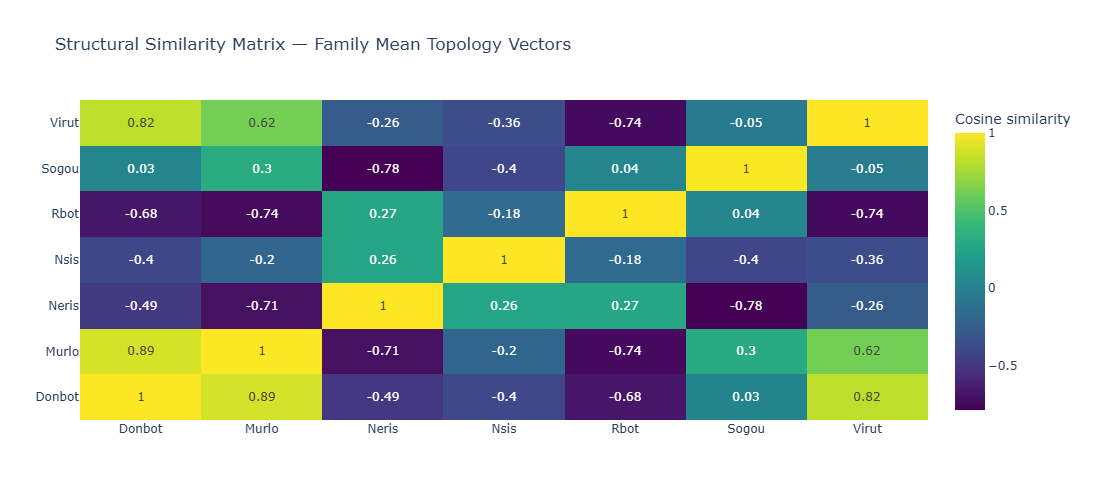

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute family mean vectors from topology metrics
family_means = metrics_df.groupby("family")[scalar_cols].mean()

# Normalize before cosine similarity
scaler = StandardScaler()
family_means_scaled = pd.DataFrame(
    scaler.fit_transform(family_means.fillna(0)),
    index=family_means.index,
    columns=family_means.columns,
)

sim_matrix = cosine_similarity(family_means_scaled)
sim_df = pd.DataFrame(sim_matrix, index=family_means.index, columns=family_means.index)

fig = go.Figure(
    go.Heatmap(
        z=sim_df.values,
        x=sim_df.columns.tolist(),
        y=sim_df.index.tolist(),
        colorscale="Viridis",
        colorbar={"title": "Cosine similarity"},
        text=sim_df.round(2).values,
        texttemplate="%{text}",
    )
)
fig.update_layout(
    title="Structural Similarity Matrix — Family Mean Topology Vectors",
    height=500,
)
fig.show()

## 2. Similarity vs. Generalization

Does structural similarity to the training set predict LOFO PR-AUC?
We compute each family's mean cosine similarity to all other families,
then scatter it against LOFO PR-AUC.

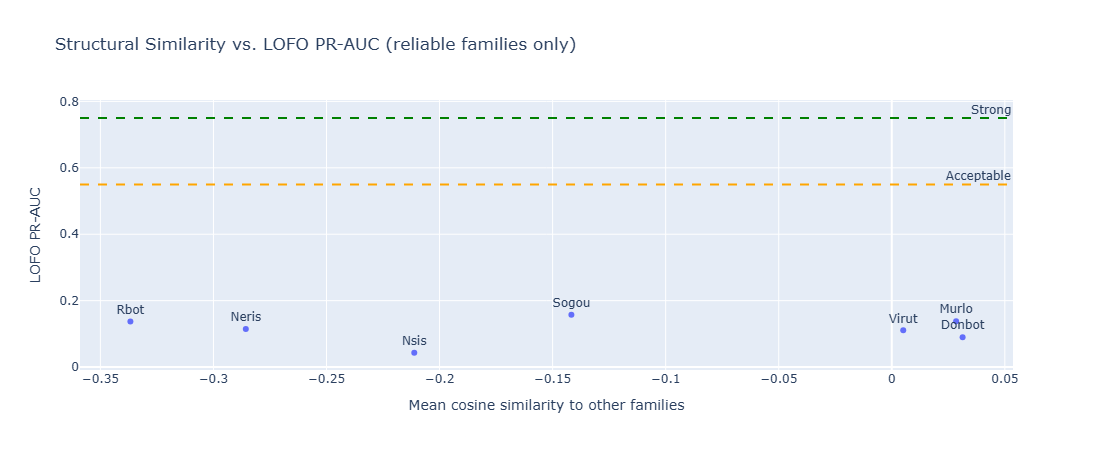

In [4]:
lofo_df = leave_one_family_out(all_features, FEATURE_COLS)

# Mean similarity to other families (exclude self-similarity)
mean_sim = {}
for fam in sim_df.index:
    others = [f for f in sim_df.index if f != fam]
    mean_sim[fam] = sim_df.loc[fam, others].mean()

lofo_df["mean_structural_similarity"] = lofo_df["family"].map(mean_sim)

reliable_lofo = lofo_df[lofo_df["reliable"] & lofo_df["pr_auc"].notna()]

fig = px.scatter(
    reliable_lofo,
    x="mean_structural_similarity",
    y="pr_auc",
    text="family",
    title="Structural Similarity vs. LOFO PR-AUC (reliable families only)",
    labels={
        "mean_structural_similarity": "Mean cosine similarity to other families",
        "pr_auc": "LOFO PR-AUC",
    },
    height=450,
)
fig.add_hline(y=0.75, line_dash="dash", line_color="green", annotation_text="Strong")
fig.add_hline(
    y=0.55, line_dash="dash", line_color="orange", annotation_text="Acceptable"
)
fig.update_traces(textposition="top center")
fig.show()

## 3. Feature Stability

Which features have the most stable signal across botnet families?
A feature with low variance across family means is a universal C2 signal.
A feature with high variance is family-specific.

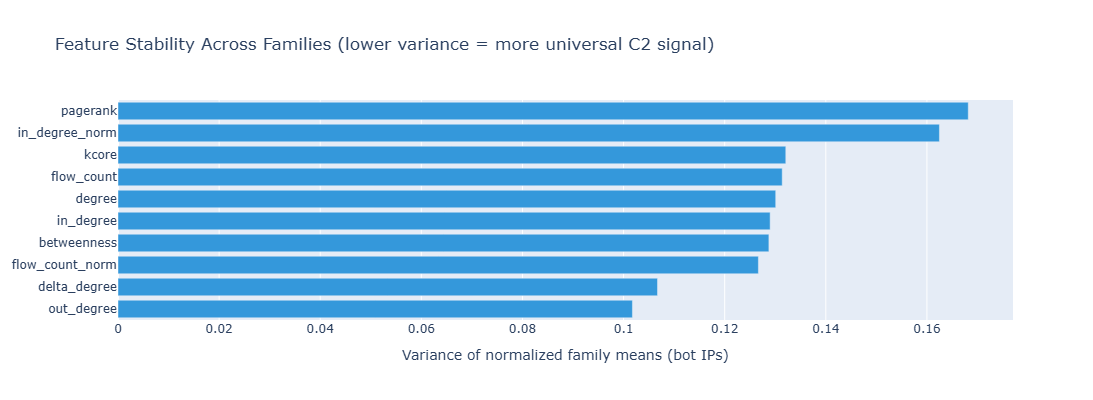


Features ranked by stability (most stable first):
        feature  variance  rank
     out_degree  0.101747     1
   delta_degree  0.106712     2
flow_count_norm  0.126663     3
    betweenness  0.128743     4
      in_degree  0.128991     5
         degree  0.130094     6
     flow_count  0.131376     7
          kcore  0.132085     8
 in_degree_norm  0.162470     9
       pagerank  0.168175    10


In [5]:
# Compute family mean feature values for bot IPs
bot_features = all_features[all_features["is_bot"]]
family_feature_means = bot_features.groupby("family")[FEATURE_COLS].mean()

# Normalize each feature to [0,1] before computing variance
family_feature_norm = (family_feature_means - family_feature_means.min()) / (
    family_feature_means.max() - family_feature_means.min() + 1e-9
)

feature_variance = family_feature_norm.var().sort_values()

fig = go.Figure(
    go.Bar(
        x=feature_variance.values,
        y=feature_variance.index,
        orientation="h",
        marker_color="#3498db",
    )
)
fig.update_layout(
    title="Feature Stability Across Families (lower variance = more universal C2 signal)",
    xaxis_title="Variance of normalized family means (bot IPs)",
    height=400,
)
fig.show()

print("\nFeatures ranked by stability (most stable first):")
stability_df = feature_variance.reset_index()
stability_df.columns = ["feature", "variance"]
stability_df["rank"] = range(1, len(stability_df) + 1)
print(stability_df.to_string(index=False))

## 4. Framing A — Exploratory PCA

> **This visualization is exploratory only.** With 13 scenarios spanning 7 families
> (4 families have exactly 1 scenario), there is no valid train/test split.
> This PCA is a visualization aid, not a classification result.

PCA of the 13-scenario structural metric vectors, colored by family.
If families cluster in topology space, it suggests the structural features
carry family-level signal beyond individual scenario noise.

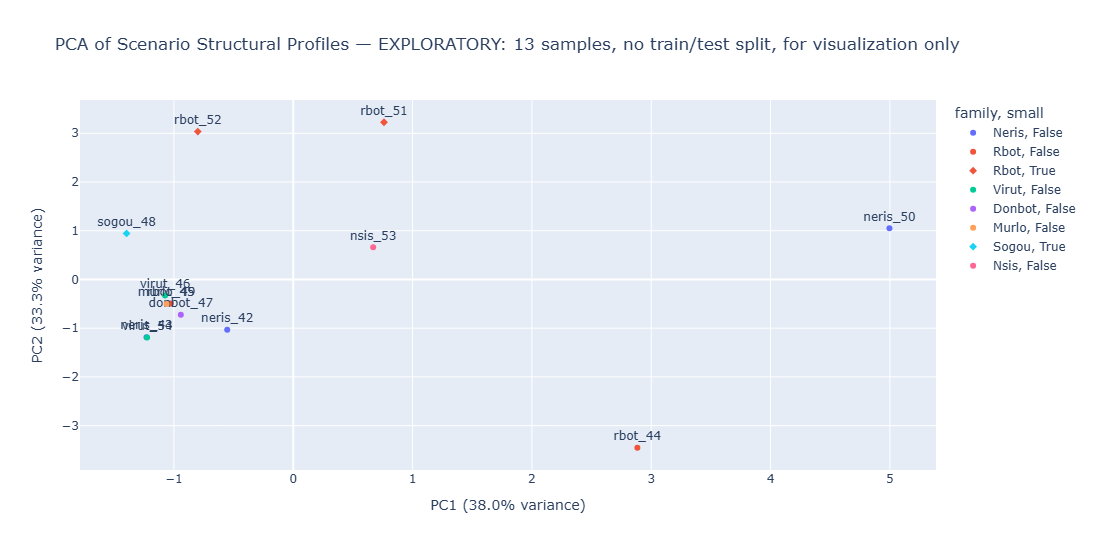

PC1 explains 38.0% of variance
PC2 explains 33.3% of variance


In [6]:
pca_data = metrics_df[scalar_cols].fillna(0)
scaler_pca = StandardScaler()
pca_scaled = scaler_pca.fit_transform(pca_data)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(pca_scaled)

pca_df = pd.DataFrame(
    {
        "PC1": components[:, 0],
        "PC2": components[:, 1],
        "scenario_id": metrics_df["scenario_id"].values,
        "family": metrics_df["family"].values,
        "small": metrics_df["small"].values,
    }
)

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="family",
    text="scenario_id",
    symbol="small",
    title=(
        "PCA of Scenario Structural Profiles — "
        "EXPLORATORY: 13 samples, no train/test split, for visualization only"
    ),
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)",
    },
    height=550,
)
fig.update_traces(textposition="top center")
fig.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0] * 100:.1f}% of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1] * 100:.1f}% of variance")

## 5. Summary

Write your summary here after seeing the actual results.

Key questions to address:
- Which features are universal C2 signals (low cross-family variance)?
- Which features are family-specific artifacts (high variance)?
- Does structural similarity predict LOFO PR-AUC? (positive correlation supports the topology hypothesis)
- Do families cluster in PCA space? What does this suggest about topology as a discriminator?